In [ ]:
import joblib
import shap
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el modelo Node-GAM
model_path = "D:\\tesis\\Modelo_extraccion_no\\node_gam\\extracción\\bal\\anybal\\best_model_fold_3.pth"
best_model = joblib.load(model_path)

# Cargar el dataset de entrenamiento y prueba
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Train_extraccion.pkl')
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\Extraccion_general\\Test_extraccion.pkl')
# Convertir X_train y X_test a DataFrame, ya que NodeGAMClassifier requiere DataFrames
X_train_df = pd.DataFrame(X_train)
X_test_df = pd.DataFrame(X_test)

# Verificar las dimensiones
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")


Dimensiones de X_train: (450, 36)
Dimensiones de X_test: (50, 36)


In [ ]:
# Función auxiliar para asegurarnos de que el input sea DataFrame
def model_predict(df):
    # Asegurarse de que el input es un DataFrame antes de pasar al modelo
    if isinstance(df, np.ndarray):
        df = pd.DataFrame(df)
    return best_model.predict(df)

# Crear el explainer SHAP con el modelo Node-GAM
explainer = shap.Explainer(model_predict, X_train_df)  # Usar una pequeña muestra del set de entrenamiento para el explainer
shap_values = explainer.shap_values(X_test_df)

# Mostrar la gráfica de resumen de importancia de características
shap.summary_plot(shap_values, X_test_df)


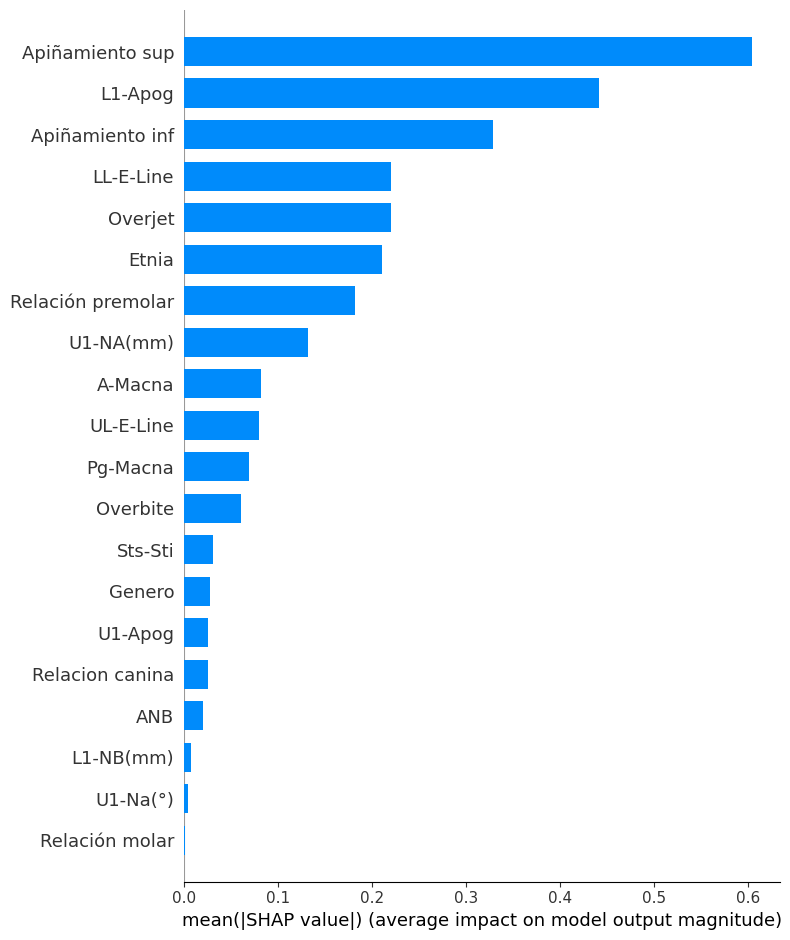

In [ ]:
# Generar el gráfico de resumen de la importancia de características
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

In [ ]:
best_model.feature_names = X_train_df.columns.tolist()

In [ ]:
X_train_df.columns.tolist()

['Edad',
 'Genero',
 'Etnia',
 'Apiñamiento sup',
 'Apiñamiento inf',
 'Overbite',
 'Overjet',
 'SNA',
 'SNB',
 'ANB',
 'A-Macna',
 'Pg-Macna',
 'IMPA',
 'SN-MP',
 'SN-GoGn',
 'Fh-Npog',
 'Ngo-GoMe',
 'NS-SGn',
 'U1-Sn',
 'U1-PP',
 'U1-NA(mm)',
 'U1-Na(°)',
 'L1-NB(mm)',
 'L1-NB(°)',
 'U1-L1',
 'L1-Apog',
 'U1-Apog',
 'Sts-Sti',
 'UL-E-Line',
 'LL-E-Line',
 'UlSn-SnPmn',
 "LLB'-B'Pog'",
 'Clasificación  esqueletica',
 'Relación molar',
 'Relación premolar',
 'Relacion canina']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

save_folder = "D:\\tesis\\Modelo_extraccion_no\\imagnes art\\partial_dependence_plots"
os.makedirs(save_folder, exist_ok=True)  # Create the folder if it doesn't exist
feature_name_mapping = {

    'Edad': "Age",
    'Genero': "Gender",
    'Etnia': "Ethnicity",
    'Apiñamiento sup': "Upper crowding",
    'Apiñamiento inf': "Lower crowding",
    'Overbite':'Overbite',
    'Overjet': 'Overjet',
    'SNA': 'SNA',
    'SNB': 'SNB',
    'ANB': 'ANB',
    'A-Macna':'A-Macna',
    'Pg-Macna':'Pg-Macna',
    'IMPA':'IMPA',
    'SN-MP':'SN-MP',
    'SN-GoGn':'SN-GoGn',
    'Fh-Npog':'Fh-Npog',
    'Ngo-GoMe':'Ngo-GoMe',
    'NS-SGn':'NS-SGn',
    'U1-Sn':'U1-Sn',
    'U1-PP':'U1-PP',
    'U1-NA(mm)':'U1-NA(mm)',
    'U1-Na(°)':'U1-Na(°)',
    'L1-NB(mm)':'L1-NB(mm)',
    'L1-NB(°)':'L1-NB(°)',
    'U1-L1':'U1-L1',
    'L1-Apog':'L1-Apog',
    'U1-Apog':'U1-Apog',
    'Sts-Sti':'Sts-Sti',
    'UL-E-Line':'UL-E-Line',
    'LL-E-Line':'LL-E-Line',
    'UlSn-SnPmn':'UlSn-SnPmn',
    "LLB'-B'Pog'":"LLB'-B'Pog'",
    'Clasificación  esqueletica': "skeletal classification",
    'Relación molar': "Molar relationship",
    'Relación premolar': "Premolar relationship",
    'Relacion canina': "Canine relationship"

    # Add the rest of your feature names here
    # "original_name": "English_name",
}
# Step 2: Replace the feature names in your model
# Assuming best_model.feature_names is a list
new_feature_names = [feature_name_mapping.get(name, name) for name in best_model.feature_names]

# Now `new_feature_names` contains the English version of your feature names
best_model.feature_names = new_feature_names  # Update the feature names in the model
# Assuming model.feature_names is already defined
for i, feature_name in enumerate(best_model.feature_names):
    plt.figure(figsize=(10, 6))

    # Generate a range of values for the feature
    x_values = np.linspace(X_train.iloc[:, i].min(), X_train.iloc[:, i].max(), 100)

    # Keep other features constant and only vary feature i
    X_sample = X_train.iloc[0, :].copy()  # Take a sample from your data
    y_values = []

    for val in x_values:
        X_sample[i] = val
        y_pred = best_model.predict(pd.DataFrame([X_sample]))  # Ensure the input is a DataFrame
        y_values.append(y_pred)  # Get predictions for each value

    # Convert y_values to numpy for further processing
    y_values = np.array(y_values).flatten()

    # Calculate the gradient (derivative) of the curve to find the inflection point
    gradients = np.gradient(y_values)
    threshold_index = np.argmax(np.abs(gradients))  # Index of the point with the biggest change

    plt.plot(x_values, y_values, label=f"Dependence of {feature_name}")

    # Add a vertical dashed line at the feature value where the biggest change occurs
    plt.axvline(x=x_values[threshold_index], color='r', linestyle='--', label=f"Decision threshold at {x_values[threshold_index]:.2f}")

    plt.title(f"Contribution of feature {feature_name}")
    plt.xlabel(f"{feature_name}")
    plt.ylabel("Model Prediction")

    # Show legend
    plt.legend()

    # Save the plot to the specified folder
    plot_path = os.path.join(save_folder, f"{feature_name}_partial_dependence.png")
    plt.savefig(plot_path)
    print(f"Plot saved for feature: {feature_name} at {plot_path}")

    # Close the plot after saving to free memory
    plt.close()

#gb

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier  # Asumiendo un modelo de clasificación
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
# Crear la carpeta para guardar las gráficas
save_folder = "/content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/Extraccion/"
os.makedirs(save_folder, exist_ok=True)

# Diccionario de mapeo de nombres de características
feature_name_mapping = {
    'Edad': "Age",
    'Genero': "Gender",
    'Etnia': "Ethnicity",
    'Apiñamiento sup': "Upper crowding",
    'Apiñamiento inf': "Lower crowding",
    'Overbite': 'Overbite',
    'Overjet': 'Overjet',
    'SNA': 'SNA',
    'SNB': 'SNB',
    'ANB': 'ANB',
    'A-Macna': 'A-Macna',
    'Pg-Macna': 'Pg-Macna',
    'IMPA': 'IMPA',
    'SN-MP': 'SN-MP',
    'SN-GoGn': 'SN-GoGn',
    'Fh-Npog': 'Fh-Npog',
    'Ngo-GoMe': 'Ngo-GoMe',
    'NS-SGn': 'NS-SGn',
    'U1-Sn': 'U1-Sn',
    'U1-PP': 'U1-PP',
    'U1-NA(mm)': 'U1-NA(mm)',
    'U1-Na(°)': 'U1-Na(°)',
    'L1-NB(mm)': 'L1-NB(mm)',
    'L1-NB(°)': 'L1-NB(°)',
    'U1-L1': 'U1-L1',
    'L1-Apog': 'L1-Apog',
    'U1-Apog': 'U1-Apog',
    'Sts-Sti': 'Sts-Sti',
    'UL-E-Line': 'UL-E-Line',
    'LL-E-Line': 'LL-E-Line',
    'UlSn-SnPmn': 'UlSn-SnPmn',
    "LLB'-B'Pog'": "LLB'-B'Pog'",
    'Clasificación esqueletica': "Skeletal classification",
    'Relación molar': "Molar relationship",
    'Relación premolar': "Premolar relationship",
    'Relacion canina': "Canine relationship"
}




import joblib

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, y_train = joblib.load('/content/Train_extraccion.pkl')
X_test, y_test = joblib.load('/content/Test_extraccion.pkl')
X_train = X_train.rename(columns={    'Edad': "Age",
    'Genero': "Gender",
    'Etnia': "Ethnicity",
    'Apiñamiento sup': "Upper crowding",
    'Apiñamiento inf': "Lower crowding",
    'Overbite':'Overbite',
    'Overjet': 'Overjet',
    'SNA': 'SNA',
    'SNB': 'SNB',
    'ANB': 'ANB',
    'A-Macna':'A-Macna',
    'Pg-Macna':'Pg-Macna',
    'IMPA':'IMPA',
    'SN-MP':'SN-MP',
    'SN-GoGn':'SN-GoGn',
    'Fh-Npog':'Fh-Npog',
    'Ngo-GoMe':'Ngo-GoMe',
    'NS-SGn':'NS-SGn',
    'U1-Sn':'U1-Sn',
    'U1-PP':'U1-PP',
    'U1-NA(mm)':'U1-NA(mm)',
    'U1-Na(°)':'U1-Na(°)',
    'L1-NB(mm)':'L1-NB(mm)',
    'L1-NB(°)':'L1-NB(°)',
    'U1-L1':'U1-L1',
    'L1-Apog':'L1-Apog',
    'U1-Apog':'U1-Apog',
    'Sts-Sti':'Sts-Sti',
    'UL-E-Line':'UL-E-Line',
    'LL-E-Line':'LL-E-Line',
    'UlSn-SnPmn':'UlSn-SnPmn',
    "LLB'-B'Pog'":"LLB'-B'Pog'",
    'Clasificación  esqueletica': "skeletal classification",
    'Relación molar': "Molar relationship",
    'Relación premolar': "Premolar relationship",
    'Relacion canina': "Canine relationship"
})



X_test = X_test.rename(columns={    'Edad': "Age",
    'Genero': "Gender",
    'Etnia': "Ethnicity",
    'Apiñamiento sup': "Upper crowding",
    'Apiñamiento inf': "Lower crowding",
    'Overbite':'Overbite',
    'Overjet': 'Overjet',
    'SNA': 'SNA',
    'SNB': 'SNB',
    'ANB': 'ANB',
    'A-Macna':'A-Macna',
    'Pg-Macna':'Pg-Macna',
    'IMPA':'IMPA',
    'SN-MP':'SN-MP',
    'SN-GoGn':'SN-GoGn',
    'Fh-Npog':'Fh-Npog',
    'Ngo-GoMe':'Ngo-GoMe',
    'NS-SGn':'NS-SGn',
    'U1-Sn':'U1-Sn',
    'U1-PP':'U1-PP',
    'U1-NA(mm)':'U1-NA(mm)',
    'U1-Na(°)':'U1-Na(°)',
    'L1-NB(mm)':'L1-NB(mm)',
    'L1-NB(°)':'L1-NB(°)',
    'U1-L1':'U1-L1',
    'L1-Apog':'L1-Apog',
    'U1-Apog':'U1-Apog',
    'Sts-Sti':'Sts-Sti',
    'UL-E-Line':'UL-E-Line',
    'LL-E-Line':'LL-E-Line',
    'UlSn-SnPmn':'UlSn-SnPmn',
    "LLB'-B'Pog'":"LLB'-B'Pog'",
    'Clasificación  esqueletica': "skeletal classification",
    'Relación molar': "Molar relationship",
    'Relación premolar': "Premolar relationship",
    'Relacion canina': "Canine relationship"
})


# Crear el modelo de Gradient Boosting
best_model = GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=200, random_state=30)
best_model.fit(X_train, y_train)

# Actualizar los nombres de las características en el modelo
new_feature_names = [feature_name_mapping.get(name, name) for name in X_train.columns]
best_model.feature_names_in_ = new_feature_names

# Generar gráficos de dependencia parcial
for i, feature_name in enumerate(new_feature_names):
    plt.figure(figsize=(10, 6))

    # Rango de valores de la característica
    x_values = np.linspace(X_train.iloc[:, i].min(), X_train.iloc[:, i].max(), 100)

    # Mantener otras características constantes y variar solo la característica i
    X_sample = X_train.iloc[0, :].copy()  # Tomar una muestra de tus datos
    y_values = []

    for val in x_values:
        X_sample[i] = val
        y_pred = best_model.predict(pd.DataFrame([X_sample]))  # Asegurarse de que la entrada sea un DataFrame
        y_values.append(y_pred)  # Obtener predicciones para cada valor

    # Convertir y_values a numpy para procesamiento adicional
    y_values = np.array(y_values).flatten()

    # Calcular la derivada para encontrar el punto de inflexión
    gradients = np.gradient(y_values)
    threshold_index = np.argmax(np.abs(gradients))  # Índice del punto con mayor cambio

    # Graficar la dependencia parcial
    plt.plot(x_values, y_values, label=f"Dependence of {feature_name}")

    # Línea vertical en el punto de cambio más grande
    plt.axvline(x=x_values[threshold_index], color='r', linestyle='--', label=f"Decision threshold at {x_values[threshold_index]:.2f}")

    plt.title(f"Contribution of feature {feature_name}")
    plt.xlabel(f"{feature_name}")
    plt.ylabel("Model Prediction")

    # Mostrar la leyenda
    plt.legend()

    # Guardar el gráfico
    plot_path = os.path.join(save_folder, f"{feature_name}_partial_dependenceExtracción.png")
    plt.savefig(plot_path)
    print(f"Plot saved for feature: {feature_name} at {plot_path}")

    # Cerrar la gráfica después de guardarla
    plt.close()


<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a futu

Plot saved for feature: Age at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/Extraccion/Age_partial_dependenceExtracción.png


<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a futu

Plot saved for feature: Gender at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/Extraccion/Gender_partial_dependenceExtracción.png


<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a futu

...

Plot saved for feature: Molar relationship at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/Extraccion/Molar relationship_partial_dependenceExtracción.png


<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a futu

Plot saved for feature: Premolar relationship at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/Extraccion/Premolar relationship_partial_dependenceExtracción.png


<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-6-059f7ae221cf>:160: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a futu

Plot saved for feature: Canine relationship at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/Extraccion/Canine relationship_partial_dependenceExtracción.png


In [7]:
X_train

,Age,Gender,Ethnicity,Upper crowding,Lower crowding,Overbite,Overjet,SNA,SNB,ANB,...,U1-Apog,Sts-Sti,UL-E-Line,LL-E-Line,UlSn-SnPmn,LLB'-B'Pog',skeletal classification,Molar relationship,Premolar relationship,Canine relationship
317,30,0,1,-4.00,-1.00,1.681000,2.641571,84.506907,80.439405,4.067503,...,-3.387128,0.000000,-4.033557,-0.829477,61.852884,153.389593,0,0,1,1
487,23,1,0,1.00,-8.00,2.470047,3.705070,76.681227,73.082046,3.599181,...,-6.718103,0.000000,-1.946573,-2.360731,66.842643,132.151808,0,1,1,1
315,19,0,1,-1.00,0.00,2.677853,3.651608,81.570894,77.586145,3.984750,...,-4.672568,0.243439,-1.097586,0.700035,79.112868,146.913683,0,2,0,0
356,20,1,1,-4.00,-2.00,2.778801,0.926270,84.047424,78.681858,5.365566,...,-8.836346,0.308762,-0.417659,2.184343,48.236999,150.546331,0,1,1,1
174,47,0,1,2.00,0.00,2.701614,0.540321,85.865636,82.332169,3.533468,...,-4.617587,0.000000,-5.274135,-3.102818,64.576592,152.047486,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48,22,0,1,-1.02,-4.93,5.361722,1.631827,82.253617,76.852264,5.401353,...,-7.939676,0.233121,-2.943650,-0.909065,81.513449,136.872896,0,0,1,1
123,38,0,0,-3.00,-4.00,3.241936,2.971771,79.645436,76.699408,2.946028,...,-4.599785,0.270157,-2.620270,-1.150846,96.331033,140.427372,0,0,1,1
40,34,0,1,-2.68,-4.86,3.263654,0.699353,83.191209,76.703441,6.487769,...,-8.679514,0.699353,-3.015051,1.605467,78.046773,157.963530,0,0,0,1
302,30,0,1,0.00,-1.00,4.802864,1.200722,85.839703,85.350074,0.489629,...,-7.935220,0.000000,-6.725158,-1.634586,85.701486,151.818249,1,1,1,1


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier  # Asumiendo un modelo de clasificación
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
# Crear la carpeta para guardar las gráficas
save_folder = "/content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/ExtraccionInf/"
os.makedirs(save_folder, exist_ok=True)

# Diccionario de mapeo de nombres de características
feature_name_mapping = {
    'Edad': "Age",
    'Genero': "Gender",
    'Etnia': "Ethnicity",
    'Apiñamiento sup': "Upper crowding",
    'Apiñamiento inf': "Lower crowding",
    'Overbite': 'Overbite',
    'Overjet': 'Overjet',
    'SNA': 'SNA',
    'SNB': 'SNB',
    'ANB': 'ANB',
    'A-Macna': 'A-Macna',
    'Pg-Macna': 'Pg-Macna',
    'IMPA': 'IMPA',
    'SN-MP': 'SN-MP',
    'SN-GoGn': 'SN-GoGn',
    'Fh-Npog': 'Fh-Npog',
    'Ngo-GoMe': 'Ngo-GoMe',
    'NS-SGn': 'NS-SGn',
    'U1-Sn': 'U1-Sn',
    'U1-PP': 'U1-PP',
    'U1-NA(mm)': 'U1-NA(mm)',
    'U1-Na(°)': 'U1-Na(°)',
    'L1-NB(mm)': 'L1-NB(mm)',
    'L1-NB(°)': 'L1-NB(°)',
    'U1-L1': 'U1-L1',
    'L1-Apog': 'L1-Apog',
    'U1-Apog': 'U1-Apog',
    'Sts-Sti': 'Sts-Sti',
    'UL-E-Line': 'UL-E-Line',
    'LL-E-Line': 'LL-E-Line',
    'UlSn-SnPmn': 'UlSn-SnPmn',
    "LLB'-B'Pog'": "LLB'-B'Pog'",
    'Clasificación esqueletica': "Skeletal classification",
    'Relación molar': "Molar relationship",
    'Relación premolar': "Premolar relationship",
    'Relacion canina': "Canine relationship"
}

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, y_train = joblib.load('/content/Train_inferior.pkl')
X_test, y_test = joblib.load('/content/Test_inferior.pkl')
X_train = X_train.rename(columns={    'Edad': "Age",
    'Genero': "Gender",
    'Etnia': "Ethnicity",
    'Apiñamiento sup': "Upper crowding",
    'Apiñamiento inf': "Lower crowding",
    'Overbite':'Overbite',
    'Overjet': 'Overjet',
    'SNA': 'SNA',
    'SNB': 'SNB',
    'ANB': 'ANB',
    'A-Macna':'A-Macna',
    'Pg-Macna':'Pg-Macna',
    'IMPA':'IMPA',
    'SN-MP':'SN-MP',
    'SN-GoGn':'SN-GoGn',
    'Fh-Npog':'Fh-Npog',
    'Ngo-GoMe':'Ngo-GoMe',
    'NS-SGn':'NS-SGn',
    'U1-Sn':'U1-Sn',
    'U1-PP':'U1-PP',
    'U1-NA(mm)':'U1-NA(mm)',
    'U1-Na(°)':'U1-Na(°)',
    'L1-NB(mm)':'L1-NB(mm)',
    'L1-NB(°)':'L1-NB(°)',
    'U1-L1':'U1-L1',
    'L1-Apog':'L1-Apog',
    'U1-Apog':'U1-Apog',
    'Sts-Sti':'Sts-Sti',
    'UL-E-Line':'UL-E-Line',
    'LL-E-Line':'LL-E-Line',
    'UlSn-SnPmn':'UlSn-SnPmn',
    "LLB'-B'Pog'":"LLB'-B'Pog'",
    'Clasificación  esqueletica': "skeletal classification",
    'Relación molar': "Molar relationship",
    'Relación premolar': "Premolar relationship",
    'Relacion canina': "Canine relationship"
})



X_test = X_test.rename(columns={    'Edad': "Age",
    'Genero': "Gender",
    'Etnia': "Ethnicity",
    'Apiñamiento sup': "Upper crowding",
    'Apiñamiento inf': "Lower crowding",
    'Overbite':'Overbite',
    'Overjet': 'Overjet',
    'SNA': 'SNA',
    'SNB': 'SNB',
    'ANB': 'ANB',
    'A-Macna':'A-Macna',
    'Pg-Macna':'Pg-Macna',
    'IMPA':'IMPA',
    'SN-MP':'SN-MP',
    'SN-GoGn':'SN-GoGn',
    'Fh-Npog':'Fh-Npog',
    'Ngo-GoMe':'Ngo-GoMe',
    'NS-SGn':'NS-SGn',
    'U1-Sn':'U1-Sn',
    'U1-PP':'U1-PP',
    'U1-NA(mm)':'U1-NA(mm)',
    'U1-Na(°)':'U1-Na(°)',
    'L1-NB(mm)':'L1-NB(mm)',
    'L1-NB(°)':'L1-NB(°)',
    'U1-L1':'U1-L1',
    'L1-Apog':'L1-Apog',
    'U1-Apog':'U1-Apog',
    'Sts-Sti':'Sts-Sti',
    'UL-E-Line':'UL-E-Line',
    'LL-E-Line':'LL-E-Line',
    'UlSn-SnPmn':'UlSn-SnPmn',
    "LLB'-B'Pog'":"LLB'-B'Pog'",
    'Clasificación  esqueletica': "skeletal classification",
    'Relación molar': "Molar relationship",
    'Relación premolar': "Premolar relationship",
    'Relacion canina': "Canine relationship"
})
# Crear el modelo de Gradient Boosting
best_model = GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=200, random_state=30)
best_model.fit(X_train, y_train)

# Actualizar los nombres de las características en el modelo
new_feature_names = [feature_name_mapping.get(name, name) for name in X_train.columns]
best_model.feature_names_in_ = new_feature_names

# Generar gráficos de dependencia parcial
for i, feature_name in enumerate(new_feature_names):
    plt.figure(figsize=(10, 6))

    # Rango de valores de la característica
    x_values = np.linspace(X_train.iloc[:, i].min(), X_train.iloc[:, i].max(), 100)

    # Mantener otras características constantes y variar solo la característica i
    X_sample = X_train.iloc[0, :].copy()  # Tomar una muestra de tus datos
    y_values = []

    for val in x_values:
        X_sample[i] = val
        y_pred = best_model.predict(pd.DataFrame([X_sample]))  # Asegurarse de que la entrada sea un DataFrame
        y_values.append(y_pred)  # Obtener predicciones para cada valor

    # Convertir y_values a numpy para procesamiento adicional
    y_values = np.array(y_values).flatten()

    # Calcular la derivada para encontrar el punto de inflexión
    gradients = np.gradient(y_values)
    threshold_index = np.argmax(np.abs(gradients))  # Índice del punto con mayor cambio

    # Graficar la dependencia parcial
    plt.plot(x_values, y_values, label=f"Dependence of {feature_name}")

    # Línea vertical en el punto de cambio más grande
    plt.axvline(x=x_values[threshold_index], color='r', linestyle='--', label=f"Decision threshold at {x_values[threshold_index]:.2f}")

    plt.title(f"Contribution of feature {feature_name}")
    plt.xlabel(f"{feature_name}")
    plt.ylabel("Model Prediction")

    # Mostrar la leyenda
    plt.legend()

    # Guardar el gráfico
    plot_path = os.path.join(save_folder, f"{feature_name}_partial_dependenceExtracciónInf.png")
    plt.savefig(plot_path)
    print(f"Plot saved for feature: {feature_name} at {plot_path}")

    # Cerrar la gráfica después de guardarla
    plt.close()


<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a futu

Plot saved for feature: Age at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/ExtraccionInf/Age_partial_dependenceExtracciónInf.png


<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a futu

Plot saved for feature: Gender at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/ExtraccionInf/Gender_partial_dependenceExtracciónInf.png


<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a futu

...

Plot saved for feature: Molar relationship at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/ExtraccionInf/Molar relationship_partial_dependenceExtracciónInf.png


<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a futu

Plot saved for feature: Premolar relationship at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/ExtraccionInf/Premolar relationship_partial_dependenceExtracciónInf.png


<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-9-5f787d18f9c7>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a futu

Plot saved for feature: Canine relationship at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/ExtraccionInf/Canine relationship_partial_dependenceExtracciónInf.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier  # Asumiendo un modelo de clasificación
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
# Crear la carpeta para guardar las gráficas
save_folder = "/content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/ExtraccionSup/"
os.makedirs(save_folder, exist_ok=True)

# Diccionario de mapeo de nombres de características
feature_name_mapping = {
    'Edad': "Age",
    'Genero': "Gender",
    'Etnia': "Ethnicity",
    'Apiñamiento sup': "Upper crowding",
    'Apiñamiento inf': "Lower crowding",
    'Overbite': 'Overbite',
    'Overjet': 'Overjet',
    'SNA': 'SNA',
    'SNB': 'SNB',
    'ANB': 'ANB',
    'A-Macna': 'A-Macna',
    'Pg-Macna': 'Pg-Macna',
    'IMPA': 'IMPA',
    'SN-MP': 'SN-MP',
    'SN-GoGn': 'SN-GoGn',
    'Fh-Npog': 'Fh-Npog',
    'Ngo-GoMe': 'Ngo-GoMe',
    'NS-SGn': 'NS-SGn',
    'U1-Sn': 'U1-Sn',
    'U1-PP': 'U1-PP',
    'U1-NA(mm)': 'U1-NA(mm)',
    'U1-Na(°)': 'U1-Na(°)',
    'L1-NB(mm)': 'L1-NB(mm)',
    'L1-NB(°)': 'L1-NB(°)',
    'U1-L1': 'U1-L1',
    'L1-Apog': 'L1-Apog',
    'U1-Apog': 'U1-Apog',
    'Sts-Sti': 'Sts-Sti',
    'UL-E-Line': 'UL-E-Line',
    'LL-E-Line': 'LL-E-Line',
    'UlSn-SnPmn': 'UlSn-SnPmn',
    "LLB'-B'Pog'": "LLB'-B'Pog'",
    'Clasificación esqueletica': "Skeletal classification",
    'Relación molar': "Molar relationship",
    'Relación premolar': "Premolar relationship",
    'Relacion canina': "Canine relationship"
}

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, y_train = joblib.load('/content/Train_superior.pkl')
X_test, y_test = joblib.load('/content/Test_superior.pkl')
X_train = X_train.rename(columns={    'Edad': "Age",
    'Genero': "Gender",
    'Etnia': "Ethnicity",
    'Apiñamiento sup': "Upper crowding",
    'Apiñamiento inf': "Lower crowding",
    'Overbite':'Overbite',
    'Overjet': 'Overjet',
    'SNA': 'SNA',
    'SNB': 'SNB',
    'ANB': 'ANB',
    'A-Macna':'A-Macna',
    'Pg-Macna':'Pg-Macna',
    'IMPA':'IMPA',
    'SN-MP':'SN-MP',
    'SN-GoGn':'SN-GoGn',
    'Fh-Npog':'Fh-Npog',
    'Ngo-GoMe':'Ngo-GoMe',
    'NS-SGn':'NS-SGn',
    'U1-Sn':'U1-Sn',
    'U1-PP':'U1-PP',
    'U1-NA(mm)':'U1-NA(mm)',
    'U1-Na(°)':'U1-Na(°)',
    'L1-NB(mm)':'L1-NB(mm)',
    'L1-NB(°)':'L1-NB(°)',
    'U1-L1':'U1-L1',
    'L1-Apog':'L1-Apog',
    'U1-Apog':'U1-Apog',
    'Sts-Sti':'Sts-Sti',
    'UL-E-Line':'UL-E-Line',
    'LL-E-Line':'LL-E-Line',
    'UlSn-SnPmn':'UlSn-SnPmn',
    "LLB'-B'Pog'":"LLB'-B'Pog'",
    'Clasificación  esqueletica': "skeletal classification",
    'Relación molar': "Molar relationship",
    'Relación premolar': "Premolar relationship",
    'Relacion canina': "Canine relationship"
})



X_test = X_test.rename(columns={    'Edad': "Age",
    'Genero': "Gender",
    'Etnia': "Ethnicity",
    'Apiñamiento sup': "Upper crowding",
    'Apiñamiento inf': "Lower crowding",
    'Overbite':'Overbite',
    'Overjet': 'Overjet',
    'SNA': 'SNA',
    'SNB': 'SNB',
    'ANB': 'ANB',
    'A-Macna':'A-Macna',
    'Pg-Macna':'Pg-Macna',
    'IMPA':'IMPA',
    'SN-MP':'SN-MP',
    'SN-GoGn':'SN-GoGn',
    'Fh-Npog':'Fh-Npog',
    'Ngo-GoMe':'Ngo-GoMe',
    'NS-SGn':'NS-SGn',
    'U1-Sn':'U1-Sn',
    'U1-PP':'U1-PP',
    'U1-NA(mm)':'U1-NA(mm)',
    'U1-Na(°)':'U1-Na(°)',
    'L1-NB(mm)':'L1-NB(mm)',
    'L1-NB(°)':'L1-NB(°)',
    'U1-L1':'U1-L1',
    'L1-Apog':'L1-Apog',
    'U1-Apog':'U1-Apog',
    'Sts-Sti':'Sts-Sti',
    'UL-E-Line':'UL-E-Line',
    'LL-E-Line':'LL-E-Line',
    'UlSn-SnPmn':'UlSn-SnPmn',
    "LLB'-B'Pog'":"LLB'-B'Pog'",
    'Clasificación  esqueletica': "skeletal classification",
    'Relación molar': "Molar relationship",
    'Relación premolar': "Premolar relationship",
    'Relacion canina': "Canine relationship"
})
# Crear el modelo de Gradient Boosting
best_model = GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=200, random_state=30)
best_model.fit(X_train, y_train)

# Actualizar los nombres de las características en el modelo
new_feature_names = [feature_name_mapping.get(name, name) for name in X_train.columns]
best_model.feature_names_in_ = new_feature_names

# Generar gráficos de dependencia parcial
for i, feature_name in enumerate(new_feature_names):
    plt.figure(figsize=(10, 6))

    # Rango de valores de la característica
    x_values = np.linspace(X_train.iloc[:, i].min(), X_train.iloc[:, i].max(), 100)

    # Mantener otras características constantes y variar solo la característica i
    X_sample = X_train.iloc[0, :].copy()  # Tomar una muestra de tus datos
    y_values = []

    for val in x_values:
        X_sample[i] = val
        y_pred = best_model.predict(pd.DataFrame([X_sample]))  # Asegurarse de que la entrada sea un DataFrame
        y_values.append(y_pred)  # Obtener predicciones para cada valor

    # Convertir y_values a numpy para procesamiento adicional
    y_values = np.array(y_values).flatten()

    # Calcular la derivada para encontrar el punto de inflexión
    gradients = np.gradient(y_values)
    threshold_index = np.argmax(np.abs(gradients))  # Índice del punto con mayor cambio

    # Graficar la dependencia parcial
    plt.plot(x_values, y_values, label=f"Dependence of {feature_name}")

    # Línea vertical en el punto de cambio más grande
    plt.axvline(x=x_values[threshold_index], color='r', linestyle='--', label=f"Decision threshold at {x_values[threshold_index]:.2f}")

    plt.title(f"Contribution of feature {feature_name}")
    plt.xlabel(f"{feature_name}")
    plt.ylabel("Model Prediction")

    # Mostrar la leyenda
    plt.legend()

    # Guardar el gráfico
    plot_path = os.path.join(save_folder, f"{feature_name}_partial_dependenceExtracciónSup.png")
    plt.savefig(plot_path)
    print(f"Plot saved for feature: {feature_name} at {plot_path}")

    # Cerrar la gráfica después de guardarla
    plt.close()


<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a 

Plot saved for feature: Age at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/ExtraccionSup/Age_partial_dependenceExtracciónSup.png


<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a 

Plot saved for feature: Gender at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/ExtraccionSup/Gender_partial_dependenceExtracciónSup.png


<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a 

...

Plot saved for feature: Molar relationship at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/ExtraccionSup/Molar relationship_partial_dependenceExtracciónSup.png


<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a 

Plot saved for feature: Premolar relationship at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/ExtraccionSup/Premolar relationship_partial_dependenceExtracciónSup.png


<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  X_sample[i] = val
<ipython-input-11-cb30ba4a3ac5>:153: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a 

Plot saved for feature: Canine relationship at /content/drive/MyDrive/PaperExtracciónDental/Imagenes de extracción/dependencia pacial/ExtraccionSup/Canine relationship_partial_dependenceExtracciónSup.png
